<a href="https://colab.research.google.com/github/Borson277/Income-Spent-Analysis-using-K-Means-Hierarchical-Clustering-/blob/main/Income_%26_Spent_Analysis_using_K_Means_%26_Hierarchical_Clustering_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
dataset = pd.read_csv('/content/KMeans Dataset.csv')

In [18]:
dataset.shape

(303, 2)

In [19]:
dataset.describe()

,INCOME,SPEND
count,303.000000,303.000000
mean,245.273927,149.646865
std,48.499412,22.905161
min,126.000000,71.000000
25%,211.000000,133.500000
50%,240.000000,153.000000
75%,274.000000,166.000000
max,417.000000,202.000000


In [5]:
dataset.head()

,INCOME,SPEND
0,233,150
1,250,187
2,204,172
3,236,178
4,354,163


In [8]:
Income = dataset['INCOME'].values
Score = dataset['SPEND'].values
X = np.array(list(zip(Income, Score)))

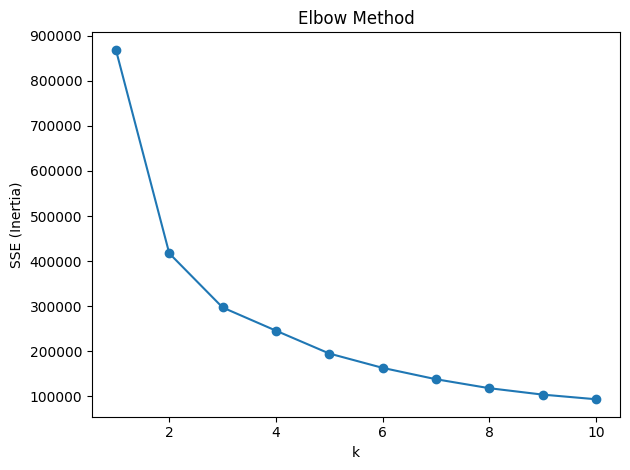

In [10]:
from sklearn.cluster import KMeans
K_MAX = 10
sse = []
for k in range(1, K_MAX+1):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(X)
  sse.append(kmeans.inertia_)

plt.figure()
plt.plot(range(1, K_MAX+1), sse, marker = 'o')
plt.xlabel("k")
plt.ylabel("SSE (Inertia)")
plt.title("Elbow Method")
plt.tight_layout()
plt.show()

In [11]:
model = KMeans(n_clusters=4, random_state=0)
y_means = model.fit_predict(X)

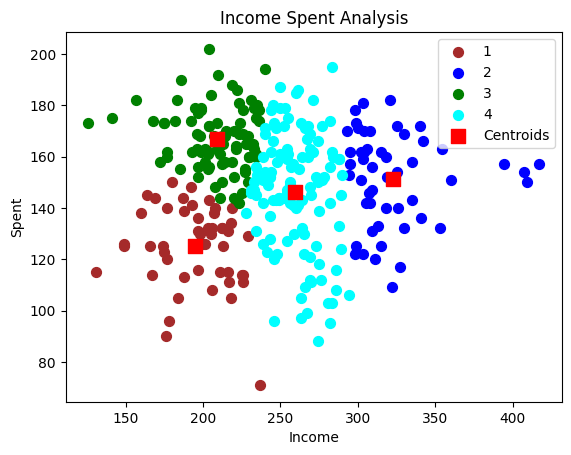

In [12]:
plt.scatter(X[y_means==0,0], X[y_means==0,1], s=50, c='brown', label='1')
plt.scatter(X[y_means==1,0], X[y_means==1,1], s=50, c='blue', label='2')
plt.scatter(X[y_means==2,0], X[y_means==2,1], s=50, c='green', label='3')
plt.scatter(X[y_means==3,0], X[y_means==3,1], s=50, c='cyan', label='4')

plt.scatter(model.cluster_centers_[:,0], model.cluster_centers_[:,1],
            s=100, marker='s', c='red', label='Centroids')

plt.title('Income Spent Analysis')
plt.xlabel('Income')
plt.ylabel('Spent')
plt.legend()
plt.show()